# Prediksi Cuaca Kabupaten Lamongan

Nama Kelompok:
- Tuhu Pangestu
- Intan Aulia Majid
- Farah Dita Artika Febrianti Sriyono
- Muhammad Umar Faruq

### Import Library

In [7]:
import matplotlib.pyplot as plt
import pandas as pd


### Load Dataset

In [8]:
df = pd.read_csv("cuaca_lamongan_harian.csv")

df.head()

,tanggal,kode_cuaca,cuaca,suhu_maks (°C),suhu_min (°C),suhu_rata (°C),kelembapan_rata (%),curah_hujan (mm),durasi_hujan (jam),kecepatan_angin_maks (km/jam),hembusan_angin_maks (km/jam),radiasi_matahari (MJ/m²)
0,2021-01-01,63,Hujan Sedang,29.35,23.95,26.027084,88.98850,10.099999,9.0,12.682018,26.640000,13.70
1,2021-01-02,61,Hujan Ringan,29.60,24.65,26.489586,87.86041,5.000000,16.0,8.699793,27.359999,13.19
2,2021-01-03,63,Hujan Sedang,30.60,24.45,26.808334,85.22653,8.500001,15.0,10.144082,28.800000,16.58
3,2021-01-04,63,Hujan Sedang,29.85,24.35,26.752089,85.02827,5.600000,8.0,10.446206,30.599998,15.22
4,2021-01-05,65,Hujan Lebat,29.10,24.25,26.089586,90.13273,33.500000,15.0,15.790833,31.319998,13.01


## Analisis Volume

Volume mengukur jumlah dan ukuran data yang digunakan. Analisis dilakukan berdasarkan jumlah baris, jumlah kolom, ukuran data, dan rentang waktu pengamatan.

In [9]:
jumlah_baris, jumlah_kolom = df.shape

print(f"Jumlah data: {jumlah_baris:,} baris")
print(f"Jumlah atribut: {jumlah_kolom} kolom")

ukuran_memori = df.memory_usage(deep=True).sum() / 1024

print(f"Ukuran DataFrame di memori: {ukuran_memori:.2f} KB")

df["tanggal"] = pd.to_datetime(df["tanggal"])

print(f"Data paling awal: {df['tanggal'].min().date()}")
print(f"Data paling akhir: {df['tanggal'].max().date()}")

data_per_tahun = df["tanggal"].dt.year.value_counts().sort_index()
display(data_per_tahun)

Jumlah data: 2,089 baris
Jumlah atribut: 12 kolom
Ukuran DataFrame di memori: 407.22 KB
Data paling awal: 2021-01-01
Data paling akhir: 2026-09-20


tanggal
2021    365
2022    365
2023    365
2024    366
2025    365
2026    263
Name: count, dtype: int64

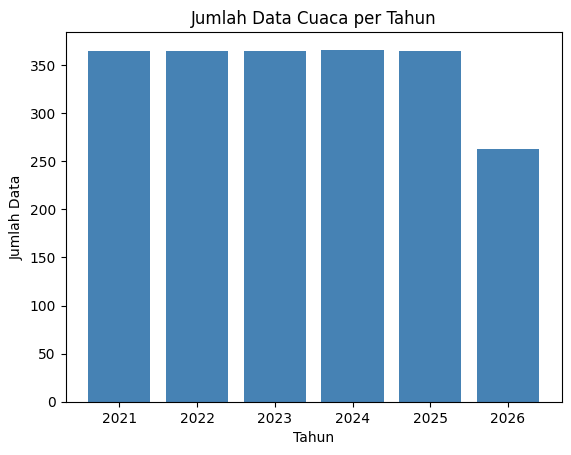

In [10]:
tahun = data_per_tahun.index.astype(str)
jumlah_data = data_per_tahun.values

plt.bar(tahun, jumlah_data, color="steelblue")

plt.title("Jumlah Data Cuaca per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Data")
plt.show()

## Analisis Velocity

Dataset cuaca ini memiliki velocity harian karena data dikumpulkan satu kali untuk setiap tanggal. Rata-rata interval antar data dapat digunakan untuk mengetahui konsistensi pengumpulan data. Jika intervalnya mendekati 1 hari, berarti data dikumpulkan secara rutin setiap hari. Jika terdapat interval lebih dari 1 hari, berarti terdapat tanggal yang tidak memiliki data.

Rata-rata interval data: 1.00 hari
Interval data yang paling sering: 1 hari
Interval minimum: 1 hari
Interval maksimum: 1 hari
Jumlah tanggal tanpa data: 0


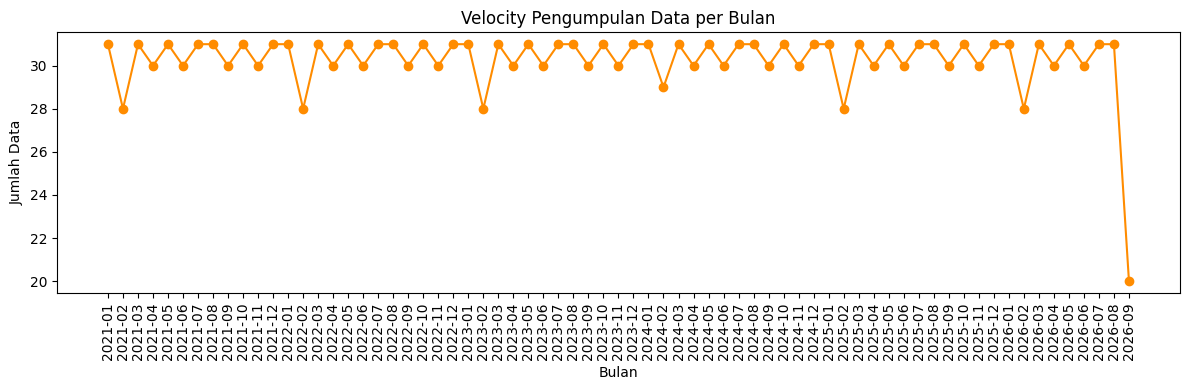

In [ ]:
df["tanggal"] = pd.to_datetime(df["tanggal"])
tanggal_urut = df["tanggal"].drop_duplicates().sort_values()

selisih_hari = tanggal_urut.diff().dt.days.dropna()

print(f"Rata-rata interval data: {selisih_hari.mean():.2f} hari")
print(f"Interval data yang paling sering: {int(selisih_hari.mode().iloc[0])} hari")
print(f"Interval minimum: {int(selisih_hari.min())} hari")
print(f"Interval maksimum: {int(selisih_hari.max())} hari")

rentang_tanggal = pd.date_range(
    start=tanggal_urut.min(),
    end=tanggal_urut.max(),
    freq="D"
)
tanggal_hilang = rentang_tanggal.difference(tanggal_urut)

print(f"Jumlah tanggal tanpa data: {len(tanggal_hilang)}")

data_per_bulan = df.groupby(df["tanggal"].dt.to_period("M")).size()

plt.figure(figsize=(12, 4))
plt.plot(
    data_per_bulan.index.astype(str),
    data_per_bulan.values,
    marker="o",
    color="darkorange"
)
plt.title("Velocity Pengumpulan Data per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Interpretasi Grafik Velocity

Grafik naik turun menunjukkan jumlah data yang tercatat pada setiap bulan. Perubahan tersebut terjadi karena jumlah hari dalam setiap bulan berbeda: ada bulan yang memiliki 28, 29, 30, atau 31 hari. September 2026 juga memiliki jumlah data lebih sedikit karena pengamatan hanya berlangsung sampai tanggal 20.

Perubahan tinggi grafik tidak menunjukkan bahwa kecepatan pengambilan data berubah-ubah. Berdasarkan interval rata-rata 1 hari, interval minimum 1 hari, interval maksimum 1 hari, dan tidak adanya tanggal yang hilang, data dikumpulkan secara konsisten setiap hari. Dengan demikian, velocity dataset ini adalah harian dan stabil.